# 05 — Geographic Analysis

## Olist E-Commerce Business Analytics

### Objective

This notebook examines how Olist’s historical marketplace performance varies across Brazilian states.

The geographic analysis covers:

- Customer and order concentration
- Delivered product and payment values
- Average order payment
- Review scores
- Delivery duration
- Late-delivery rates
- State-level performance comparisons
- Geographic opportunities and operational risks
- Choropleth maps using Brazilian state GeoJSON boundaries

The results describe observed geographic patterns and do not establish that customer location causes differences in satisfaction, delivery, or spending.

In [20]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

try:
    import geopandas as gpd
    print("GeoPandas version:", gpd.__version__)
    print("GeoPandas is available.")
except ImportError:
    print("GeoPandas is not installed.")


GeoPandas version: 1.1.3
GeoPandas is available.


In [19]:
COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

In [21]:
PROCESSED_DATA_DIR = Path("../data/processed").resolve()
REFERENCE_DATA_DIR = Path("../data/reference").resolve()
IMAGE_OUTPUT_DIR = Path(
    "../images/notebook_outputs"
).resolve()

REFERENCE_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed data:", PROCESSED_DATA_DIR.exists())
print("Reference data:", REFERENCE_DATA_DIR.exists())
print("Image output:", IMAGE_OUTPUT_DIR.exists())

Processed data: True
Reference data: True
Image output: True


## 1. Load Brazilian State Boundaries

The Brazilian state GeoJSON contains polygon boundaries for the 26 states and the Federal District. It will be used to create state-level choropleth maps.


In [22]:
geojson_files = sorted(
    REFERENCE_DATA_DIR.glob("*.geojson")
)

print("GeoJSON files found:", len(geojson_files))

for file in geojson_files:
    print("-", file.name)

GeoJSON files found: 2
- brazil-states.geojson
- brazil_states_validated.geojson


In [23]:
GEOJSON_PATH = (
    REFERENCE_DATA_DIR
    / "brazil-states.geojson"
)

brazil_states = gpd.read_file(
    GEOJSON_PATH
)

print("Geographic records:", len(brazil_states))
print("Coordinate reference system:", brazil_states.crs)
print("Columns:", brazil_states.columns.tolist())

brazil_states.head()

Geographic records: 27
Coordinate reference system: EPSG:4326
Columns: ['id', 'name', 'sigla', 'regiao_id', 'codigo_ibg', 'cartodb_id', 'created_at', 'updated_at', 'geometry']


,id,name,sigla,regiao_id,codigo_ibg,cartodb_id,created_at,updated_at,geometry
0,1,Acre,AC,3,12,1,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-73.60818 -7.20194, -72.86963 ..."
1,2,Alagoas,AL,4,27,2,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-35.46516 -8.82549, -35.46626 ..."
2,3,Amazonas,AM,3,13,3,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-67.32553 2.03012, -67.32234 2..."
3,4,Amapá,AP,3,16,4,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-51.18168 4.00889, -51.179 3.9..."
4,5,Bahia,BA,4,29,5,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-39.2882 -8.5629, -39.28229 -8..."


In [24]:
geojson_validation = pd.DataFrame([
    {
        "validation_check": "Geographic records",
        "result": len(brazil_states),
        "expected": 27
    },
    {
        "validation_check": "Missing geometries",
        "result": brazil_states.geometry.isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid geometries",
        "result": (
            ~brazil_states.geometry.is_valid
        ).sum(),
        "expected": 0
    }
])

geojson_validation["status"] = np.where(
    geojson_validation["result"]
    == geojson_validation["expected"],
    "Passed",
    "Failed"
)

geojson_validation

,validation_check,result,expected,status
0,Geographic records,27,27,Passed
1,Missing geometries,0,0,Passed
2,Invalid geometries,11,0,Failed


### 1.1 Validate and Repair State Geometries

The GeoJSON contains all 27 Brazilian federative units, but 11 polygon geometries fail geometric-validity checks. Invalid polygons can cause missing areas, plotting errors, or unreliable spatial operations, so they will be repaired in a separate working copy.

In [25]:
brazil_states_clean = brazil_states.copy()

invalid_before = (
    ~brazil_states_clean.geometry.is_valid
).sum()

brazil_states_clean["geometry"] = (
    brazil_states_clean.geometry.make_valid()
)

brazil_states_clean["sigla"] = (
    brazil_states_clean["sigla"]
    .astype("string")
    .str.strip()
    .str.upper()
)

invalid_after = (
    ~brazil_states_clean.geometry.is_valid
).sum()

print("Invalid geometries before repair:", invalid_before)
print("Invalid geometries after repair:", invalid_after)
print(
    "Unique state abbreviations:",
    brazil_states_clean["sigla"].nunique()
)

Invalid geometries before repair: 11
Invalid geometries after repair: 0
Unique state abbreviations: 27


In [26]:
repaired_geojson_validation = pd.DataFrame([
    {
        "validation_check": "Geographic records",
        "result": len(brazil_states_clean),
        "expected": 27
    },
    {
        "validation_check": "Unique state abbreviations",
        "result": brazil_states_clean["sigla"].nunique(),
        "expected": 27
    },
    {
        "validation_check": "Missing geometries",
        "result": brazil_states_clean.geometry.isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid geometries",
        "result": (
            ~brazil_states_clean.geometry.is_valid
        ).sum(),
        "expected": 0
    }
])

repaired_geojson_validation["status"] = np.where(
    repaired_geojson_validation["result"]
    == repaired_geojson_validation["expected"],
    "Passed",
    "Failed"
)

repaired_geojson_validation

,validation_check,result,expected,status
0,Geographic records,27,27,Passed
1,Unique state abbreviations,27,27,Passed
2,Missing geometries,0,0,Passed
3,Invalid geometries,0,0,Passed


In [27]:
VALIDATED_GEOJSON_PATH = (
    REFERENCE_DATA_DIR
    / "brazil_states_validated.geojson"
)

brazil_states_clean[
    ["sigla", "name", "geometry"]
].to_file(
    VALIDATED_GEOJSON_PATH,
    driver="GeoJSON"
)

print(
    "Validated GeoJSON created:",
    VALIDATED_GEOJSON_PATH.exists()
)

Validated GeoJSON created: True


***Observation:*** The source GeoJSON contained all 27 federative units, but 11 geometries were invalid.

***Cleaning decision:*** Invalid geometries were repaired in a separate GeoDataFrame using geometric validation. The original downloaded GeoJSON was preserved unchanged.

***Validation:*** The repaired file contains 27 unique state abbreviations, no missing geometries, and no invalid geometries.

## 2. Load Geographic Business Data

The order-level analytical table provides customer state, order status, financial values, review scores, and validated delivery measures. Customer location is used because the analysis evaluates where marketplace demand and customer experience occurred.

In [28]:
order_analytics = pd.read_csv(
    PROCESSED_DATA_DIR / "order_analytics.csv",
    dtype={
        "customer_zip_code_prefix": "string"
    },
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print("Orders loaded:", f"{len(order_analytics):,}")
print(
    "Customer states represented:",
    order_analytics["customer_state"].nunique()
)

Orders loaded: 99,441
Customer states represented: 27


In [29]:
state_orders = order_analytics.copy()

state_orders["is_delivered_order"] = (
    state_orders["order_status"] == "delivered"
)

state_orders["delivered_product_value"] = (
    state_orders["product_value"]
    .where(state_orders["is_delivered_order"])
)

state_orders["delivered_payment_value"] = (
    state_orders["total_payment_value"]
    .where(state_orders["is_delivered_order"])
)

state_orders["delivered_review_score"] = (
    state_orders["latest_review_score"]
    .where(state_orders["is_delivered_order"])
)

state_orders["valid_delivery_days"] = (
    state_orders["delivery_days"]
    .where(
        state_orders[
            "is_valid_for_delivery_analysis"
        ]
    )
)

state_orders["valid_late_delivery"] = (
    state_orders["is_late_delivery"]
    .where(
        state_orders[
            "is_valid_for_delivery_analysis"
        ]
    )
)

In [30]:
state_performance = (
    state_orders
    .groupby("customer_state", as_index=False)
    .agg(
        unique_customers=("customer_unique_id", "nunique"),
        recorded_orders=("order_id", "nunique"),
        delivered_orders=("is_delivered_order", "sum"),
        delivered_product_value=(
            "delivered_product_value",
            "sum"
        ),
        delivered_payment_value=(
            "delivered_payment_value",
            "sum"
        ),
        average_order_payment=(
            "delivered_payment_value",
            "mean"
        ),
        reviewed_delivered_orders=(
            "delivered_review_score",
            "count"
        ),
        average_review_score=(
            "delivered_review_score",
            "mean"
        ),
        valid_delivery_orders=(
            "valid_delivery_days",
            "count"
        ),
        average_delivery_days=(
            "valid_delivery_days",
            "mean"
        ),
        late_delivery_rate=(
            "valid_late_delivery",
            "mean"
        )
    )
)

state_performance["delivered_order_rate"] = (
    state_performance["delivered_orders"]
    / state_performance["recorded_orders"]
)

state_performance = state_performance.sort_values(
    "delivered_payment_value",
    ascending=False
).reset_index(drop=True)

state_performance.style.format({
    "unique_customers": "{:,.0f}",
    "recorded_orders": "{:,.0f}",
    "delivered_orders": "{:,.0f}",
    "delivered_product_value": "R$ {:,.2f}",
    "delivered_payment_value": "R$ {:,.2f}",
    "average_order_payment": "R$ {:,.2f}",
    "reviewed_delivered_orders": "{:,.0f}",
    "average_review_score": "{:.2f}",
    "valid_delivery_orders": "{:,.0f}",
    "average_delivery_days": "{:.2f}",
    "late_delivery_rate": "{:.2%}",
    "delivered_order_rate": "{:.2%}"
})

,customer_state,unique_customers,recorded_orders,delivered_orders,delivered_product_value,delivered_payment_value,average_order_payment,reviewed_delivered_orders,average_review_score,valid_delivery_orders,average_delivery_days,late_delivery_rate,delivered_order_rate
0,SP,"40,302","41,746","40,501","R$ 5,067,633.16","R$ 5,770,266.19",R$ 142.48,"40,273",4.25,"40,427",8.77,4.50%,97.02%
1,RJ,"12,384","12,852","12,350","R$ 1,759,651.13","R$ 2,055,690.45",R$ 166.45,"12,211",3.97,"12,330",15.32,12.12%,96.09%
2,MG,"11,259","11,635","11,354","R$ 1,552,481.83","R$ 1,819,277.61",R$ 160.23,"11,285",4.19,"11,327",12.02,4.58%,97.58%
3,RS,"5,277","5,466","5,345","R$ 728,897.47","R$ 861,802.40",R$ 161.24,"5,327",4.18,"5,327",15.32,6.10%,97.79%
4,PR,"4,882","5,045","4,923","R$ 666,063.51","R$ 781,919.55",R$ 158.83,"4,900",4.24,"4,912",12.00,4.05%,97.58%
5,SC,"3,534","3,637","3,546","R$ 507,012.13","R$ 595,208.40",R$ 167.85,"3,519",4.13,"3,534",14.98,8.23%,97.50%
6,BA,"3,277","3,380","3,256","R$ 493,584.14","R$ 591,270.60",R$ 181.59,"3,229",3.93,"3,252",19.34,12.15%,96.33%
7,DF,"2,075","2,140","2,080","R$ 296,498.41","R$ 346,146.17",R$ 166.42,"2,070",4.13,"2,077",12.98,5.68%,97.20%
8,GO,"1,952","2,020","1,957","R$ 282,836.70","R$ 334,294.22",R$ 170.82,"1,946",4.10,"1,951",15.63,6.56%,96.88%
9,ES,"1,964","2,033","1,995","R$ 268,643.45","R$ 317,682.65",R$ 159.24,"1,969",4.08,"1,989",15.81,10.76%,98.13%


In [31]:
olist_states = set(
    state_performance["customer_state"]
)

geojson_states = set(
    brazil_states_clean["sigla"]
)

print("Olist states:", len(olist_states))
print("GeoJSON states:", len(geojson_states))
print(
    "Olist states missing from GeoJSON:",
    sorted(olist_states - geojson_states)
)
print(
    "GeoJSON states missing from Olist:",
    sorted(geojson_states - olist_states)
)

Olist states: 27
GeoJSON states: 27
Olist states missing from GeoJSON: []
GeoJSON states missing from Olist: []


***Validation:*** All 27 customer-state abbreviations match the GeoJSON state codes. No Olist state or geographic boundary is missing from either dataset.

In [32]:
state_performance.head(5).style.format({
    "unique_customers": "{:,.0f}",
    "recorded_orders": "{:,.0f}",
    "delivered_orders": "{:,.0f}",
    "delivered_product_value": "R$ {:,.2f}",
    "delivered_payment_value": "R$ {:,.2f}",
    "average_order_payment": "R$ {:,.2f}",
    "reviewed_delivered_orders": "{:,.0f}",
    "average_review_score": "{:.2f}",
    "valid_delivery_orders": "{:,.0f}",
    "average_delivery_days": "{:.2f}",
    "late_delivery_rate": "{:.2%}",
    "delivered_order_rate": "{:.2%}"
})

,customer_state,unique_customers,recorded_orders,delivered_orders,delivered_product_value,delivered_payment_value,average_order_payment,reviewed_delivered_orders,average_review_score,valid_delivery_orders,average_delivery_days,late_delivery_rate,delivered_order_rate
0,SP,"40,302","41,746","40,501","R$ 5,067,633.16","R$ 5,770,266.19",R$ 142.48,"40,273",4.25,"40,427",8.77,4.50%,97.02%
1,RJ,"12,384","12,852","12,350","R$ 1,759,651.13","R$ 2,055,690.45",R$ 166.45,"12,211",3.97,"12,330",15.32,12.12%,96.09%
2,MG,"11,259","11,635","11,354","R$ 1,552,481.83","R$ 1,819,277.61",R$ 160.23,"11,285",4.19,"11,327",12.02,4.58%,97.58%
3,RS,"5,277","5,466","5,345","R$ 728,897.47","R$ 861,802.40",R$ 161.24,"5,327",4.18,"5,327",15.32,6.10%,97.79%
4,PR,"4,882","5,045","4,923","R$ 666,063.51","R$ 781,919.55",R$ 158.83,"4,900",4.24,"4,912",12.00,4.05%,97.58%


***Observation:*** São Paulo recorded the highest delivered payment value at R$5.77 million and 40,501 delivered orders. It represents approximately 37.4% of delivered payment value and 42.0% of delivered orders, showing that marketplace activity is highly concentrated in SP.

***Regional contrast:*** Rio de Janeiro ranked second by delivered payment value but had a lower average review score of 3.97, a longer average delivery time of 15.32 days, and a 12.12% late-delivery rate. São Paulo recorded an average score of 4.25, 8.77 delivery days, and a 4.50% late-delivery rate.

***Interpretation:*** High commercial value does not necessarily imply strong operational performance. Rio de Janeiro is an important market where delivery and satisfaction require deeper investigation.

In [33]:
state_map_data = (
    brazil_states_clean[
        ["sigla", "name", "geometry"]
    ]
    .merge(
        state_performance,
        left_on="sigla",
        right_on="customer_state",
        how="left",
        validate="one_to_one"
    )
)

state_map_validation = pd.DataFrame([
    {
        "validation_check": "Mapped states",
        "result": len(state_map_data),
        "expected": 27
    },
    {
        "validation_check": "States missing business metrics",
        "result": state_map_data[
            "recorded_orders"
        ].isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "States missing geometry",
        "result": state_map_data[
            "geometry"
        ].isna().sum(),
        "expected": 0
    }
])

state_map_validation["status"] = np.where(
    state_map_validation["result"]
    == state_map_validation["expected"],
    "Passed",
    "Failed"
)

state_map_validation

,validation_check,result,expected,status
0,Mapped states,27,27,Passed
1,States missing business metrics,0,0,Passed
2,States missing geometry,0,0,Passed


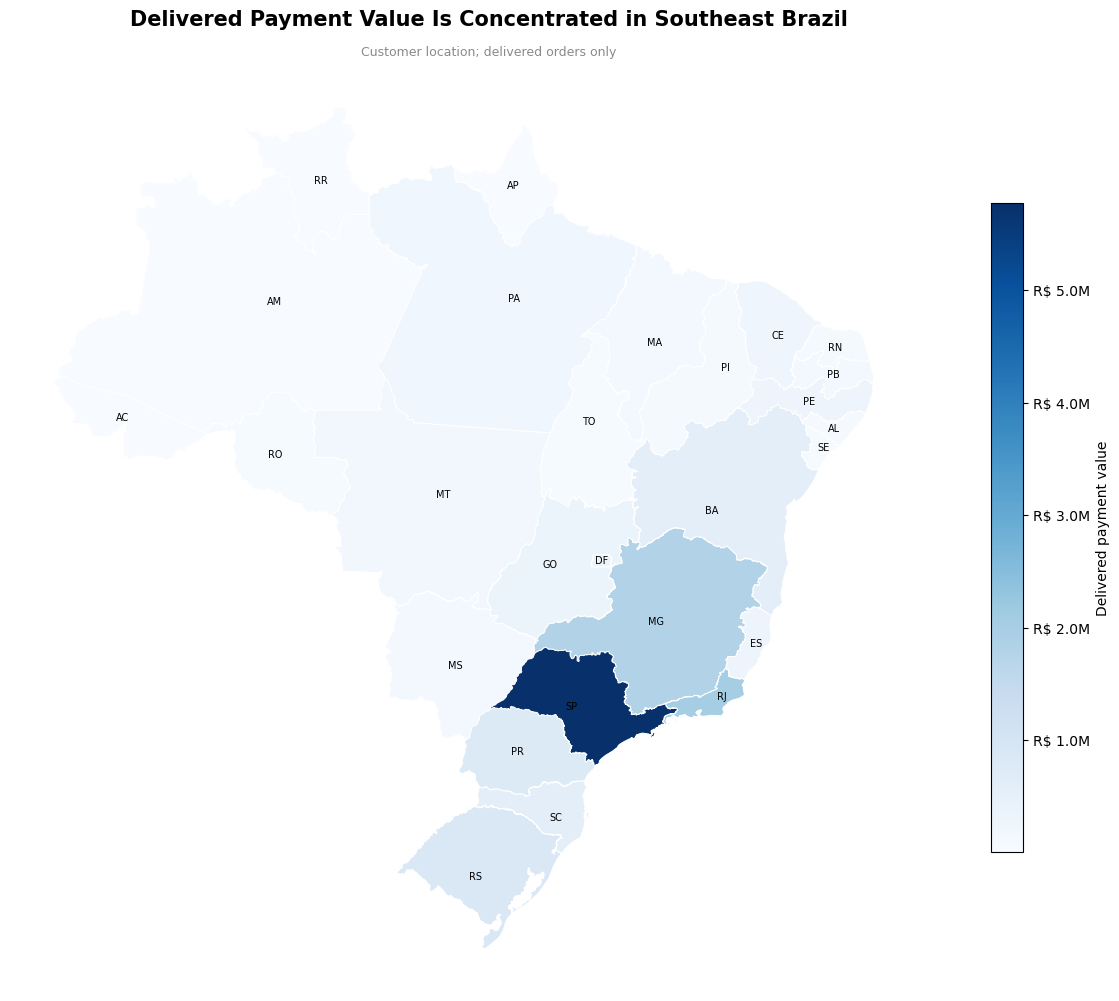

In [40]:
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(12, 10))

color_norm = Normalize(
    vmin=state_map_data["delivered_payment_value"].min(),
    vmax=state_map_data["delivered_payment_value"].max()
)

state_map_data.plot(
    column="delivered_payment_value",
    cmap="Blues",
    norm=color_norm,
    linewidth=0.7,
    edgecolor="white",
    legend=False,
    ax=ax
)

label_points = state_map_data.copy()

label_points["label_point"] = (
    label_points.geometry.representative_point()
)

for _, row in label_points.iterrows():
    ax.annotate(
        text=row["sigla"],
        xy=(
            row["label_point"].x,
            row["label_point"].y
        ),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

colour_mapper = plt.cm.ScalarMappable(
    norm=color_norm,
    cmap="Blues"
)

colour_mapper.set_array([])

colour_bar = fig.colorbar(
    colour_mapper,
    ax=ax,
    shrink=0.70,
    pad=0.02
)

colour_bar.set_label(
    "Delivered payment value",
    fontsize=10
)

colour_bar.ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda value, position:
        f"R$ {value / 1_000_000:.1f}M"
    )
)

ax.set_title(
    "Delivered Payment Value Is Concentrated in Southeast Brazil",
    fontsize=15,
    fontweight="bold",
    pad=28
)

ax.text(
    0.5,
    1.01,
    "Customer location; delivered orders only",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color=COLORS["neutral"]
)

label_colour = (
    "white"
    if row["delivered_payment_value"]
    > state_map_data["delivered_payment_value"].max() * 0.60
    else "black"
)

ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "state_delivered_payment_value_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. State Delivery Performance

Late-delivery rates are compared across states using valid delivered orders. Rankings require at least 500 valid deliveries, while the map will retain all states for geographic completeness.

In [41]:
MINIMUM_VALID_DELIVERIES = 500

reliable_state_comparison = (
    state_performance.loc[
        state_performance["valid_delivery_orders"]
        >= MINIMUM_VALID_DELIVERIES
    ]
    .sort_values(
        "late_delivery_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "States meeting the minimum:",
    len(reliable_state_comparison)
)

reliable_state_comparison[
    [
        "customer_state",
        "valid_delivery_orders",
        "average_delivery_days",
        "late_delivery_rate",
        "average_review_score",
        "delivered_payment_value"
    ]
].head(10).style.format({
    "valid_delivery_orders": "{:,.0f}",
    "average_delivery_days": "{:.2f}",
    "late_delivery_rate": "{:.2%}",
    "average_review_score": "{:.2f}",
    "delivered_payment_value": "R$ {:,.2f}"
})

States meeting the minimum: 17


,customer_state,valid_delivery_orders,average_delivery_days,late_delivery_rate,average_review_score,delivered_payment_value
0,MA,714,21.61,17.51%,3.83,"R$ 147,807.29"
1,CE,"1,278",21.27,13.77%,3.94,"R$ 266,463.97"
2,BA,"3,252",19.34,12.15%,3.93,"R$ 591,270.60"
3,RJ,"12,330",15.32,12.12%,3.97,"R$ 2,055,690.45"
4,PA,945,23.78,11.22%,3.91,"R$ 212,027.55"
5,ES,"1,989",15.81,10.76%,4.08,"R$ 317,682.65"
6,PB,517,20.43,10.44%,4.08,"R$ 137,834.65"
7,MS,699,15.65,9.73%,4.16,"R$ 134,421.54"
8,PE,"1,592",18.45,9.61%,4.08,"R$ 309,074.59"
9,SC,"3,534",14.98,8.23%,4.13,"R$ 595,208.40"


***Observation:*** Among the 17 states with at least 500 valid deliveries, Maranhão recorded the highest late-delivery rate at 17.51%, followed by Ceará at 13.77%, Bahia at 12.15%, and Rio de Janeiro at 12.12%.

***Business priority:*** Rio de Janeiro represents the most commercially significant risk among the high-delay states, with R$2.06 million in delivered payment value and 12,330 valid deliveries. Maranhão has a higher late-delivery rate but a considerably smaller transaction base.

***Customer-experience pattern:*** The states with the highest late-delivery rates also generally report review scores below the national delivered-order average of 4.16. This is consistent with the earlier delivery-satisfaction relationship but does not establish geographic causation.

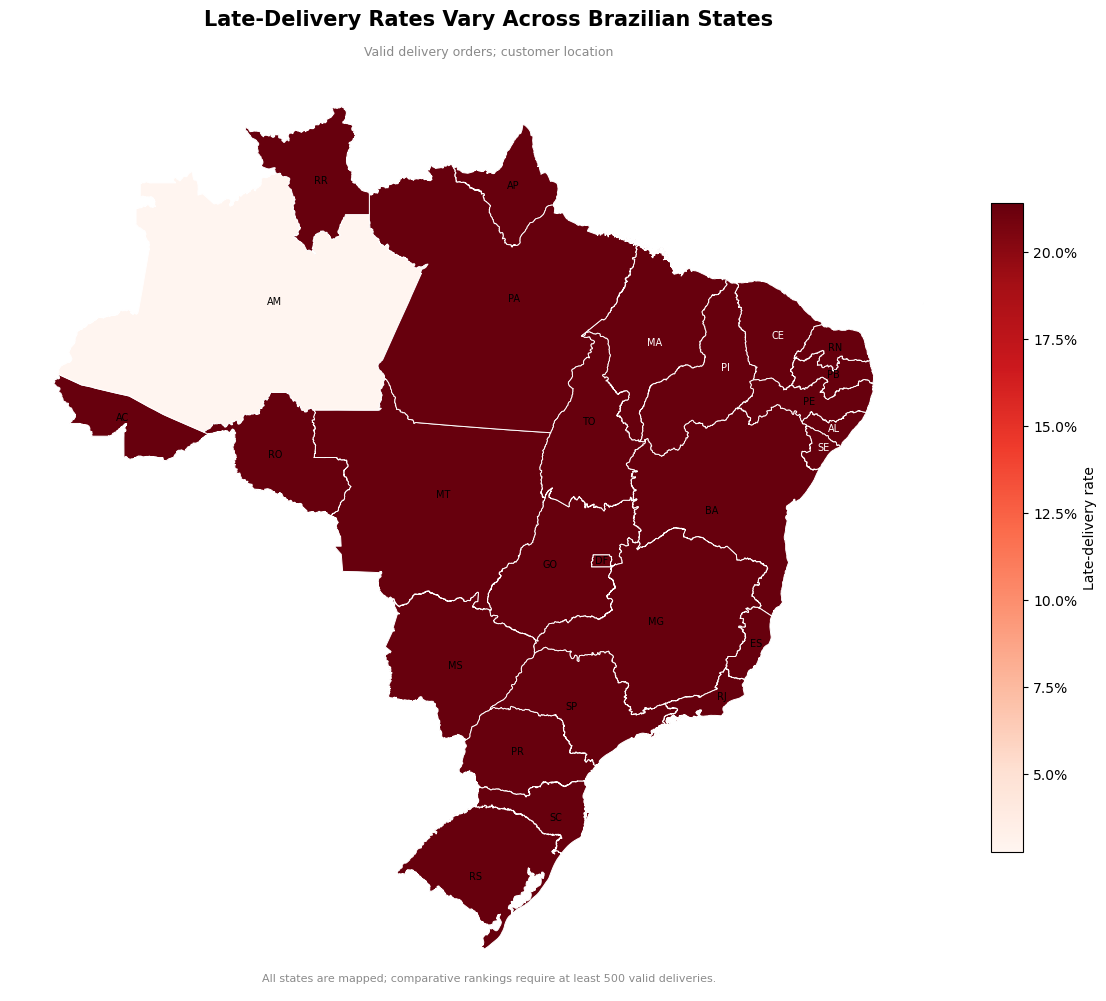

In [42]:
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(12, 10))

late_rate_norm = Normalize(
    vmin=state_map_data["late_delivery_rate"].min(),
    vmax=state_map_data["late_delivery_rate"].max()
)

state_map_data.plot(
    column="late_delivery_rate",
    cmap="Reds",
    norm=late_rate_norm,
    linewidth=0.7,
    edgecolor="white",
    legend=False,
    ax=ax
)

label_points = state_map_data.copy()

label_points["label_point"] = (
    label_points.geometry.representative_point()
)

for _, row in label_points.iterrows():
    label_colour = (
        "white"
        if row["late_delivery_rate"]
        > state_map_data["late_delivery_rate"].max() * 0.60
        else "black"
    )

    ax.annotate(
        text=row["sigla"],
        xy=(
            row["label_point"].x,
            row["label_point"].y
        ),
        ha="center",
        va="center",
        fontsize=7,
        color=label_colour
    )

colour_mapper = plt.cm.ScalarMappable(
    norm=late_rate_norm,
    cmap="Reds"
)

colour_mapper.set_array([])

colour_bar = fig.colorbar(
    colour_mapper,
    ax=ax,
    shrink=0.70,
    pad=0.02
)

colour_bar.set_label(
    "Late-delivery rate",
    fontsize=10
)

colour_bar.ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

ax.set_title(
    "Late-Delivery Rates Vary Across Brazilian States",
    fontsize=15,
    fontweight="bold",
    pad=28
)

ax.text(
    0.5,
    1.01,
    "Valid delivery orders; customer location",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color=COLORS["neutral"]
)

ax.text(
    0.5,
    0.01,
    "All states are mapped; comparative rankings require at least 500 valid deliveries.",
    transform=ax.transAxes,
    ha="center",
    fontsize=8,
    color=COLORS["neutral"]
)

ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "state_late_delivery_rate_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Map interpretation:*** Late-delivery performance varies meaningfully by customer state. Higher rates appear across several northern and northeastern markets and in Rio de Janeiro, while the Southeast does not display uniform performance.

***Volume limitation:*** The map includes all 27 states for completeness, but rates from low-volume states are less stable. Business prioritisation should consider both the rate and the number and value of affected orders.

## 4. State Customer Satisfaction

Average review scores are compared by customer state using the latest recorded review for delivered orders. Rankings require at least 500 reviewed orders to reduce instability from small samples.

In [43]:
MINIMUM_REVIEWED_ORDERS = 500

national_average_review = (
    state_orders["delivered_review_score"].mean()
)

reliable_satisfaction_comparison = (
    state_performance.loc[
        state_performance["reviewed_delivered_orders"]
        >= MINIMUM_REVIEWED_ORDERS
    ]
    .sort_values(
        "average_review_score",
        ascending=True
    )
    .reset_index(drop=True)
)

print(
    "National delivered-order review average:",
    f"{national_average_review:.2f}"
)

print(
    "States meeting the review minimum:",
    len(reliable_satisfaction_comparison)
)

reliable_satisfaction_comparison[
    [
        "customer_state",
        "reviewed_delivered_orders",
        "average_review_score",
        "late_delivery_rate",
        "average_delivery_days",
        "delivered_payment_value"
    ]
].head(10).style.format({
    "reviewed_delivered_orders": "{:,.0f}",
    "average_review_score": "{:.2f}",
    "late_delivery_rate": "{:.2%}",
    "average_delivery_days": "{:.2f}",
    "delivered_payment_value": "R$ {:,.2f}"
})

National delivered-order review average: 4.16
States meeting the review minimum: 17


,customer_state,reviewed_delivered_orders,average_review_score,late_delivery_rate,average_delivery_days,delivered_payment_value
0,MA,712,3.83,17.51%,21.61,"R$ 147,807.29"
1,PA,933,3.91,11.22%,23.78,"R$ 212,027.55"
2,BA,"3,229",3.93,12.15%,19.34,"R$ 591,270.60"
3,CE,"1,273",3.94,13.77%,21.27,"R$ 266,463.97"
4,RJ,"12,211",3.97,12.12%,15.32,"R$ 2,055,690.45"
5,PB,512,4.08,10.44%,20.43,"R$ 137,834.65"
6,ES,"1,969",4.08,10.76%,15.81,"R$ 317,682.65"
7,PE,"1,579",4.08,9.61%,18.45,"R$ 309,074.59"
8,GO,"1,946",4.10,6.56%,15.63,"R$ 334,294.22"
9,DF,"2,070",4.13,5.68%,12.98,"R$ 346,146.17"


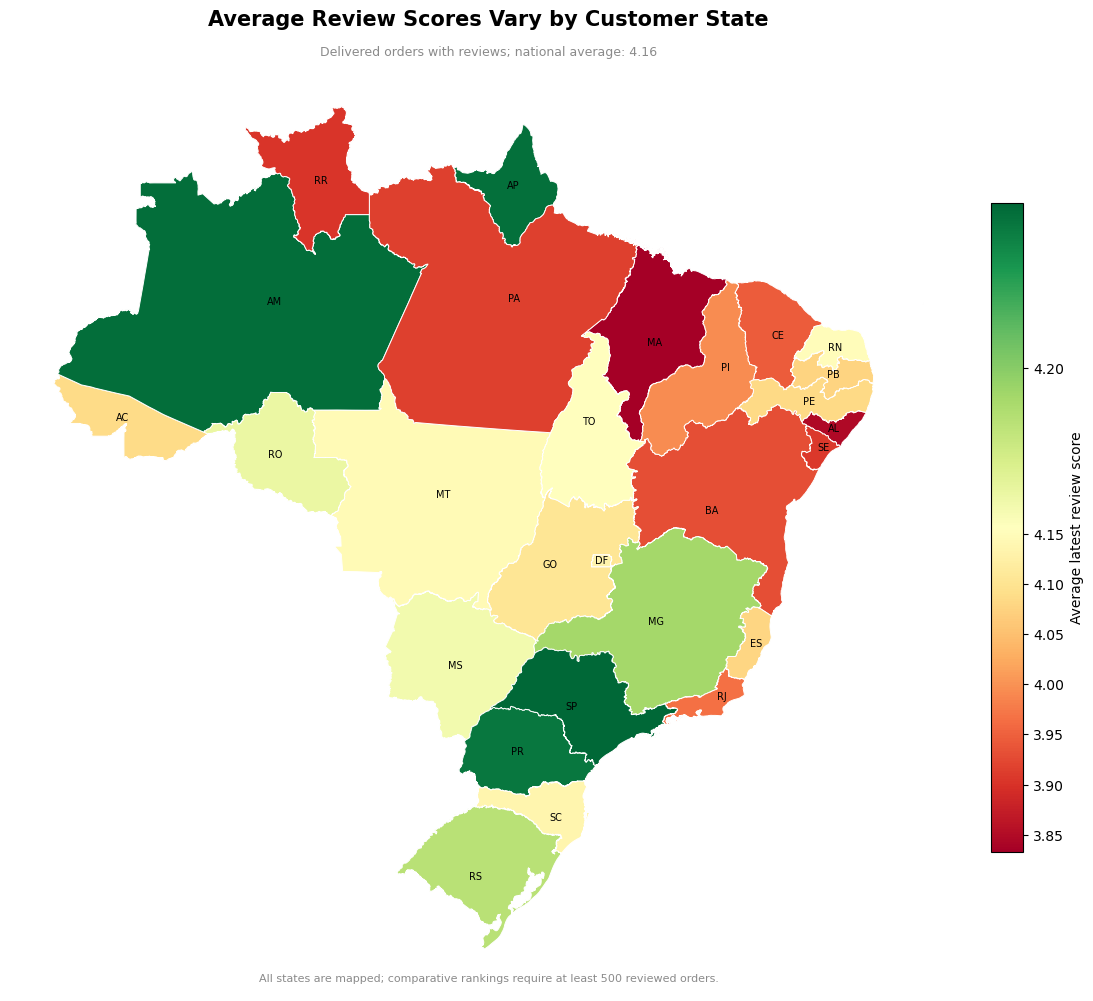

In [44]:
from matplotlib.colors import TwoSlopeNorm

review_norm = TwoSlopeNorm(
    vmin=state_map_data["average_review_score"].min(),
    vcenter=national_average_review,
    vmax=state_map_data["average_review_score"].max()
)

fig, ax = plt.subplots(figsize=(12, 10))

state_map_data.plot(
    column="average_review_score",
    cmap="RdYlGn",
    norm=review_norm,
    linewidth=0.7,
    edgecolor="white",
    legend=False,
    ax=ax
)

label_points = state_map_data.copy()

label_points["label_point"] = (
    label_points.geometry.representative_point()
)

for _, row in label_points.iterrows():
    ax.annotate(
        text=row["sigla"],
        xy=(
            row["label_point"].x,
            row["label_point"].y
        ),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

colour_mapper = plt.cm.ScalarMappable(
    norm=review_norm,
    cmap="RdYlGn"
)

colour_mapper.set_array([])

colour_bar = fig.colorbar(
    colour_mapper,
    ax=ax,
    shrink=0.70,
    pad=0.02
)

colour_bar.set_label(
    "Average latest review score",
    fontsize=10
)

colour_bar.ax.yaxis.set_major_formatter(
    mtick.FormatStrFormatter("%.2f")
)

ax.set_title(
    "Average Review Scores Vary by Customer State",
    fontsize=15,
    fontweight="bold",
    pad=28
)

ax.text(
    0.5,
    1.01,
    f"Delivered orders with reviews; national average: {national_average_review:.2f}",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color=COLORS["neutral"]
)

ax.text(
    0.5,
    0.01,
    "All states are mapped; comparative rankings require at least 500 reviewed orders.",
    transform=ax.transAxes,
    ha="center",
    fontsize=8,
    color=COLORS["neutral"]
)

ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "state_average_review_score_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Methodology:*** The diverging colour scale is centred on the national average review score. Red states fall below the national average, while green states are above it.

***Limitation:*** Average state scores summarise reviewed delivered orders and do not represent customers who submitted no review. Geographic differences may also reflect delivery, seller, category, and order-mix effects.

***Observation:*** Maranhão recorded the lowest average review score at 3.83, followed by Pará at 3.91, Bahia at 3.93, Ceará at 3.94, and Rio de Janeiro at 3.97. Each is below the national reviewed delivered-order average of approximately 4.16.

***Operational relationship:*** The lowest-scoring states generally also display longer delivery times and higher late-delivery rates. This geographic alignment supports delivery performance as an important diagnostic factor, although differences in sellers, products, freight, and customer expectations may also contribute.

***Business priority:*** Rio de Janeiro stands out because its below-average satisfaction and 12.12% late-delivery rate affect a substantially larger commercial base—more than R$2.05 million in delivered payment value.

In [45]:
national_late_delivery_rate = (
    state_orders.loc[
        state_orders["is_valid_for_delivery_analysis"],
        "is_late_delivery"
    ].mean()
)

priority_state_data = state_performance.loc[
    (
        state_performance["valid_delivery_orders"]
        >= 500
    )
    & (
        state_performance["reviewed_delivered_orders"]
        >= 500
    )
].copy()

priority_state_data["bubble_size"] = (
    150
    + 1_350
    * (
        priority_state_data["delivered_payment_value"]
        / priority_state_data[
            "delivered_payment_value"
        ].max()
    )
)

print(
    "National late-delivery rate:",
    f"{national_late_delivery_rate:.2%}"
)

print(
    "National average review score:",
    f"{national_average_review:.2f}"
)

National late-delivery rate: 6.78%
National average review score: 4.16


In [46]:
priority_candidates = (
    priority_state_data.loc[
        (
            priority_state_data["late_delivery_rate"]
            > national_late_delivery_rate
        )
        & (
            priority_state_data["average_review_score"]
            < national_average_review
        )
    ]
    .sort_values(
        "delivered_payment_value",
        ascending=False
    )
    [
        [
            "customer_state",
            "valid_delivery_orders",
            "late_delivery_rate",
            "average_review_score",
            "delivered_payment_value"
        ]
    ]
    .reset_index(drop=True)
)

priority_candidates.style.format({
    "valid_delivery_orders": "{:,.0f}",
    "late_delivery_rate": "{:.2%}",
    "average_review_score": "{:.2f}",
    "delivered_payment_value": "R$ {:,.2f}"
})

,customer_state,valid_delivery_orders,late_delivery_rate,average_review_score,delivered_payment_value
0,RJ,"12,330",12.12%,3.97,"R$ 2,055,690.45"
1,SC,"3,534",8.23%,4.13,"R$ 595,208.40"
2,BA,"3,252",12.15%,3.93,"R$ 591,270.60"
3,ES,"1,989",10.76%,4.08,"R$ 317,682.65"
4,PE,"1,592",9.61%,4.08,"R$ 309,074.59"
5,CE,"1,278",13.77%,3.94,"R$ 266,463.97"
6,PA,945,11.22%,3.91,"R$ 212,027.55"
7,MA,714,17.51%,3.83,"R$ 147,807.29"
8,PB,517,10.44%,4.08,"R$ 137,834.65"


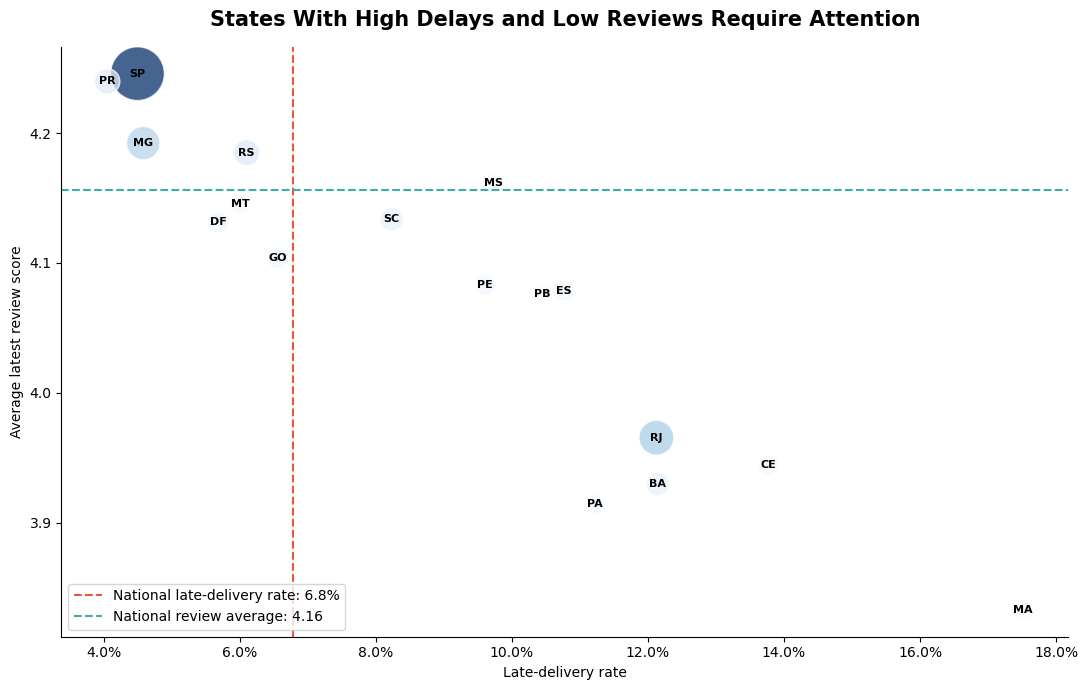

In [47]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    priority_state_data["late_delivery_rate"],
    priority_state_data["average_review_score"],
    s=priority_state_data["bubble_size"],
    c=priority_state_data["delivered_payment_value"],
    cmap="Blues",
    alpha=0.75,
    edgecolor="white",
    linewidth=1
)

for _, row in priority_state_data.iterrows():
    ax.annotate(
        row["customer_state"],
        (
            row["late_delivery_rate"],
            row["average_review_score"]
        ),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold"
    )

ax.axvline(
    national_late_delivery_rate,
    color=COLORS["negative"],
    linestyle="--",
    linewidth=1.5,
    label=(
        "National late-delivery rate: "
        f"{national_late_delivery_rate:.1%}"
    )
)

ax.axhline(
    national_average_review,
    color=COLORS["positive"],
    linestyle="--",
    linewidth=1.5,
    label=(
        "National review average: "
        f"{national_average_review:.2f}"
    )
)

ax.set_title(
    "States With High Delays and Low Reviews Require Attention",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Late-delivery rate")
ax.set_ylabel("Average latest review score")

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

ax.legend(loc="lower left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "state_delivery_satisfaction_priority_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Nine sufficiently represented states combine a late-delivery rate above the national benchmark of 6.78% with an average review score below 4.16.

***Business priority:*** Rio de Janeiro is the leading investigation priority because it combines a 12.12% late-delivery rate, a 3.97 average review score, 12,330 valid deliveries, and R$2.06 million in delivered payment value. Bahia and Santa Catarina form the next-largest commercially exposed candidates.

***Rate-versus-impact distinction:*** Maranhão has the highest late-delivery rate and lowest review score, but its observed transaction value is considerably smaller. Priorities should therefore consider both operational severity and the size of the affected business activity.

***Analytical boundary:*** These states are investigation candidates, not proven causes of revenue loss. Seller mix, product mix, logistics distance, and other unobserved factors may influence their results.

## 6. Export Geographic Outputs

State-level performance metrics and priority candidates are exported for later use in Power BI, seller analysis, delivery analysis, and the executive presentation.

In [48]:
state_performance_path = (
    PROCESSED_DATA_DIR
    / "state_performance.csv"
)

priority_candidates_path = (
    PROCESSED_DATA_DIR
    / "geographic_priority_candidates.csv"
)

state_performance.to_csv(
    state_performance_path,
    index=False
)

priority_candidates.to_csv(
    priority_candidates_path,
    index=False
)

print(
    "State performance created:",
    state_performance_path.exists()
)

print(
    "Priority candidates created:",
    priority_candidates_path.exists()
)

print(
    "Validated GeoJSON created:",
    VALIDATED_GEOJSON_PATH.exists()
)

State performance created: True
Priority candidates created: True
Validated GeoJSON created: True


In [49]:
expected_geographic_charts = [
    "state_delivered_payment_value_map.png",
    "state_late_delivery_rate_map.png",
    "state_average_review_score_map.png",
    "state_delivery_satisfaction_priority_matrix.png"
]

geographic_chart_validation = pd.DataFrame({
    "chart_file": expected_geographic_charts,
    "file_created": [
        (IMAGE_OUTPUT_DIR / filename).exists()
        for filename in expected_geographic_charts
    ]
})

geographic_chart_validation

,chart_file,file_created
0,state_delivered_payment_value_map.png,True
1,state_late_delivery_rate_map.png,True
2,state_average_review_score_map.png,True
3,state_delivery_satisfaction_priority_matrix.png,True


In [50]:
print(
    "Geographic charts exported:",
    geographic_chart_validation[
        "file_created"
    ].sum()
)

print(
    "All geographic charts created:",
    geographic_chart_validation[
        "file_created"
    ].all()
)

Geographic charts exported: 4
All geographic charts created: True


## Conclusion

***Overall result:*** Geographic analysis revealed substantial differences in marketplace scale, delivery performance, and customer satisfaction across Brazilian states.

***Commercial concentration:*** São Paulo represented approximately 37.4% of delivered payment value and 42.0% of delivered orders, making it the dominant customer market in the dataset.

***Operational priority:*** Rio de Janeiro is the most commercially significant investigation candidate because it combines high delivered payment value with an above-average late-delivery rate and below-average review score.

***Regional pattern:*** Maranhão, Ceará, Bahia, Pará, and several other states also recorded elevated late-delivery rates and below-average satisfaction. These differences require deeper seller, logistics, and product-mix analysis.

***Analytical boundaries:*** State-level associations do not establish geographic causation or guaranteed financial impact. Low-volume states require additional caution, and customer population size, logistics costs, margins, and external market conditions are unavailable.

***Outputs:*** The state-performance table, geographic-priority table, validated Brazilian state GeoJSON, and four geographic charts were saved successfully.

***Next step:*** `06_delivery_performance_analytics.ipynb` will investigate delivery duration, lateness, estimated deadlines, satisfaction effects, category patterns, and operational risk in greater detail.